In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("newplacementdata.csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df["placement_exam_marks"].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: xlabel='placement_exam_marks'>

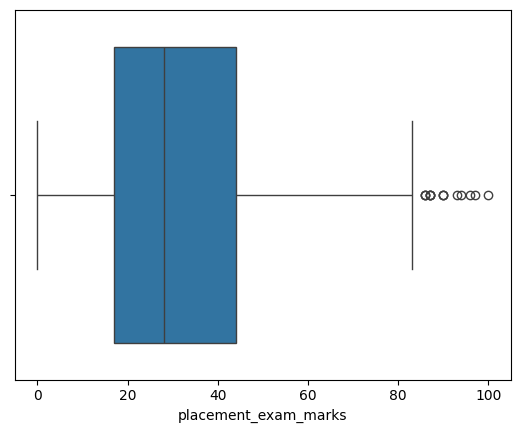

In [6]:
sns.boxplot(x = df["placement_exam_marks"])

In [7]:
# finding the IRQ

percentile25 = df["placement_exam_marks"].quantile(0.25)
percentile75 = df["placement_exam_marks"].quantile(0.75)


In [8]:
percentile25

np.float64(17.0)

In [9]:
percentile75

np.float64(44.0)

In [10]:
IQR = percentile75-percentile25

In [11]:
IQR

np.float64(27.0)

In [12]:
upper_limit = percentile75+ 1.5*IQR
upper_limit

np.float64(84.5)

In [13]:
lower_limit = percentile25-1.5*IQR
lower_limit

np.float64(-23.5)

In [14]:
# Finding outlier

In [16]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


In [17]:
df[df['placement_exam_marks']< lower_limit]

,cgpa,placement_exam_marks,placed


In [18]:
#Trimming (outlier removig technique 1)

In [20]:
newdf = df[df['placement_exam_marks']<upper_limit]

In [21]:
# comparison

Text(0.5, 1.0, 'After Trimming')

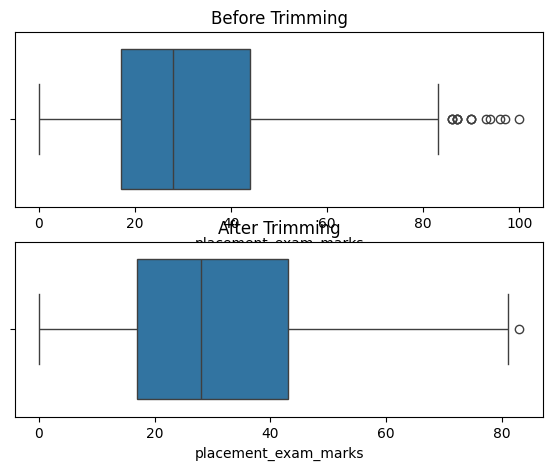

In [23]:
plt.figure(figsize = (15,5))

plt.subplot(222)
sns.boxplot(x=df["placement_exam_marks"])
plt.title("Before Trimming")

plt.subplot(224)
sns.boxplot(x=newdf["placement_exam_marks"])
plt.title("After Trimming")

In [24]:
# Caping  (Outlier removing technique 2)

In [25]:
new_df_cap = df.copy()

In [27]:
new_df_cap["placement_exam_marks"]=np.where(
    new_df_cap['placement_exam_marks'] > upper_limit ,
    upper_limit,



    np.where(
        new_df_cap['placement_exam_marks'] <lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [28]:

new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


Text(0.5, 1.0, 'After Caping')

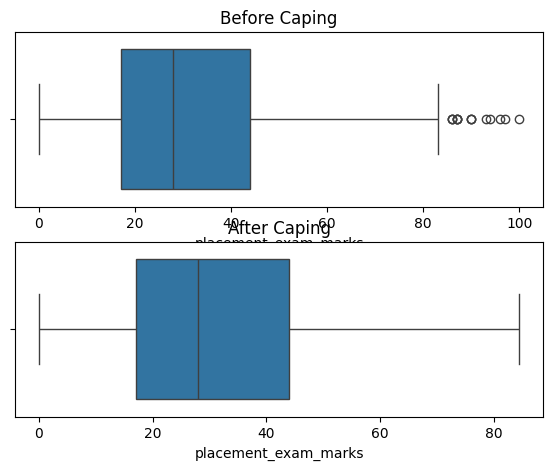

In [30]:
plt.figure(figsize = (15,5))

plt.subplot(222)
sns.boxplot(x=df["placement_exam_marks"])
plt.title("Before Caping")

plt.subplot(224)
sns.boxplot(x=new_df_cap["placement_exam_marks"])
plt.title("After Caping")